In [1]:
# If not installed already
# !pip install pytorch-forecasting lightning pandas numpy scikit-learn

import pandas as pd
import numpy as np

import torch
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping

from pytorch_forecasting import (
    TimeSeriesDataSet,
    TemporalFusionTransformer
)

from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import RMSE
from pytorch_forecasting.metrics import QuantileLoss

from sklearn.metrics import mean_absolute_error, r2_score

/Users/yashraj146/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
csv_path = "/Users/yashraj146/Downloads/Demand Forecast/sales_data.csv"   # change path if needed
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.head()

Shape: (10000, 20)


,distributor_id,industry,sku,category,sales,avg_quarterly_sales,movement_category,quarter,year,total_quarter_sales,prev_quarter_sales,is_diwali,is_ganesh_chaturthi,is_gudi_padwa,is_eid,is_akshay_tritiya,is_dussehra_navratri,is_onam,is_christmas,time_idx
0,DIST036,Healthcare,MDH Garam Masala,Food,4726.09,6345.93,Fast Moving,2,2022,4726.09,9533.64,0,0,1,0,1,0,0,0,26645
1,DIST007,E-commerce,Shell Helix Ultra 4L,Automotive,4015.00,4141.90,Slow Moving,3,2023,4015.00,3504.12,0,1,0,1,0,1,1,0,4927
2,DIST012,Retail,PlayStation 5 Digital Edition,Toys,12386.14,13593.10,Medium,2,2024,12386.14,11915.21,0,0,1,1,1,0,0,0,8683
3,DIST034,E-commerce,PlayStation 5 Digital Edition,Toys,13198.10,13593.10,Medium,4,2020,13198.10,9534.84,1,0,0,1,0,1,0,1,25185
4,DIST009,Manufacturing,Britannia Good Day Cookies,Food,3148.80,4600.58,Medium,1,2023,3148.80,5176.39,0,0,1,1,0,0,0,0,6160


In [3]:
df["date"] = pd.PeriodIndex(
    df["year"].astype(str) + "Q" + df["quarter"].astype(str),
    freq="Q"
)

In [4]:
full_data = []

festival_cols = [
    "is_diwali", "is_ganesh_chaturthi", "is_gudi_padwa",
    "is_eid", "is_akshay_tritiya", "is_dussehra_navratri",
    "is_onam", "is_christmas"
]

for (dist, sku), group in df.groupby(["distributor_id", "sku"]):

    group = group.sort_values("date")

    min_date = group["date"].min()
    max_date = group["date"].max()

    full_range = pd.period_range(min_date, max_date, freq="Q")

    full_df = pd.DataFrame({"date": full_range})
    full_df["distributor_id"] = dist
    full_df["sku"] = sku

    merged = full_df.merge(
        group,
        on=["distributor_id", "sku", "date"],
        how="left"
    )

    # Fill sales gaps with 0
    merged["sales"] = merged["sales"].fillna(0)

    # Forward/backward fill static features
    for col in ["industry", "category", "movement_category"]:
        merged[col] = merged[col].ffill().bfill()

    # Fill lag-like numeric features
    for col in ["avg_quarterly_sales", "total_quarter_sales", "prev_quarter_sales"]:
        if col in merged.columns:
            merged[col] = merged[col].fillna(0)

    # Festival flags
    for col in festival_cols:
        if col in merged.columns:
            merged[col] = merged[col].fillna(0)

    full_data.append(merged)

df = pd.concat(full_data).reset_index(drop=True)

print("After rebuilding grid:", df.shape)

After rebuilding grid: (30055, 21)


In [5]:
df = df.sort_values(["distributor_id", "sku", "date"])

df["time_idx"] = (
    df.groupby(["distributor_id", "sku"])
      .cumcount()
)

df.head()

,date,distributor_id,sku,industry,category,sales,avg_quarterly_sales,movement_category,quarter,year,...,prev_quarter_sales,is_diwali,is_ganesh_chaturthi,is_gudi_padwa,is_eid,is_akshay_tritiya,is_dussehra_navratri,is_onam,is_christmas,time_idx
0,2021Q3,DIST001,Asian Paints Apcolite Premium Enamel,Manufacturing,Paint and ancillaries,4653.29,6108.35,Slow Moving,3.0,2021.0,...,5508.39,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0
1,2021Q4,DIST001,Asian Paints Apcolite Premium Enamel,Manufacturing,Paint and ancillaries,0.00,0.00,Slow Moving,NaN,NaN,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,2022Q1,DIST001,Asian Paints Apcolite Premium Enamel,Manufacturing,Paint and ancillaries,0.00,0.00,Slow Moving,NaN,NaN,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2022Q2,DIST001,Asian Paints Apcolite Premium Enamel,Manufacturing,Paint and ancillaries,0.00,0.00,Slow Moving,NaN,NaN,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,2022Q3,DIST001,Asian Paints Apcolite Premium Enamel,Manufacturing,Paint and ancillaries,4654.22,6108.35,Fast Moving,3.0,2022.0,...,5267.76,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,4


In [6]:
max_time = df["time_idx"].max()
training_cutoff = max_time - 1

print("Max time:", max_time)
print("Training cutoff:", training_cutoff)

Max time: 23
Training cutoff: 22


In [7]:
max_encoder_length = 24
max_prediction_length = 1

training = TimeSeriesDataSet(
    df[df.time_idx <= training_cutoff],

    time_idx="time_idx",
    target="sales",
    group_ids=["distributor_id", "sku"],

    static_categoricals=[
        "distributor_id",
        "sku",
        "industry",
        "category",
        "movement_category"
    ],

    time_varying_known_reals=[
        "time_idx",
        "is_diwali",
        "is_ganesh_chaturthi",
        "is_gudi_padwa",
        "is_eid",
        "is_akshay_tritiya",
        "is_dussehra_navratri",
        "is_onam",
        "is_christmas"
    ],

    time_varying_unknown_reals=[
        "sales",
        "avg_quarterly_sales",
        "total_quarter_sales",
        "prev_quarter_sales"
    ],

    target_normalizer=GroupNormalizer(
        groups=["distributor_id", "sku"]
    ),

    min_encoder_length=6,
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

/Users/yashraj146/Library/Python/3.9/lib/python/site-packages/pytorch_forecasting/data/timeseries.py:1831: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 50 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__distributor_id': 'DIST001', '__group_id__sku': 'Dr. Morepen Glucometer'}, {'__group_id__distributor_id': 'DIST005', '__group_id__sku': 'Britannia Good Day Cookies'}, {'__group_id__distributor_id': 'DIST005', '__group_id__sku': "Kellogg's Corn Flakes"}, {'__group_id__distributor_id': 'DIST006', '__group_id__sku': 'Ajanta Wall Clock'}, {'__group_id__distributor_id': 'DIST007', '__group_id__sku': 'Nivia Basketball'}, {'__group_id__distributor_id': 'DIST010', '__group_id__sku': 'AccuCheck Sugar Test Strips'}, {'__group_id__distributor_id': 'DIST010', '__group_id__sku': 'Nerolac Beauty Gold Washable'}, {'__

In [8]:
validation = TimeSeriesDataSet.from_dataset(
    training,
    df,
    predict=True,
    stop_randomization=True
)

/Users/yashraj146/Library/Python/3.9/lib/python/site-packages/pytorch_forecasting/data/timeseries.py:1831: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 50 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__distributor_id': 'DIST001', '__group_id__sku': 'Dr. Morepen Glucometer'}, {'__group_id__distributor_id': 'DIST005', '__group_id__sku': 'Britannia Good Day Cookies'}, {'__group_id__distributor_id': 'DIST005', '__group_id__sku': "Kellogg's Corn Flakes"}, {'__group_id__distributor_id': 'DIST006', '__group_id__sku': 'Ajanta Wall Clock'}, {'__group_id__distributor_id': 'DIST007', '__group_id__sku': 'Nivia Basketball'}, {'__group_id__distributor_id': 'DIST010', '__group_id__sku': 'AccuCheck Sugar Test Strips'}, {'__group_id__distributor_id': 'DIST010', '__group_id__sku': 'Nerolac Beauty Gold Washable'}, {'__

In [9]:
train_dataloader = training.to_dataloader(
    train=True,
    batch_size=64,
    num_workers=0
)

val_dataloader = validation.to_dataloader(
    train=False,
    batch_size=64,
    num_workers=0
)

In [10]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=32,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=16,
    output_size=1,
    loss=RMSE(),
    reduce_on_plateau_patience=4,
)

print(f"Number of parameters: {tft.size()/1e3:.1f}k")

/Users/yashraj146/Library/Python/3.9/lib/python/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/Users/yashraj146/Library/Python/3.9/lib/python/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


Number of parameters: 117.0k


In [11]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    mode="min"
)

trainer = Trainer(
    max_epochs=30,
    accelerator="auto",
    gradient_clip_val=0.1,
    callbacks=[early_stop],
)

trainer.fit(tft, train_dataloader, val_dataloader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | RMSE                            | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 7.0 K  | train
3  | prescalers                         | ModuleDict                      | 544    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 7.1 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 29.8 K | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 20.6 K | train
7  | static_context_variable_selection  | GatedResidualNetw

Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/Users/yashraj146/Library/Python/3.9/lib/python/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/yashraj146/Library/Python/3.9/lib/python/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

<h2>Predict</h2>

In [12]:
best_model = tft

predictions = best_model.predict(val_dataloader)
actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/yashraj146/Library/Python/3.9/lib/python/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


In [13]:
# Move to CPU before converting to numpy
preds = predictions.detach().cpu().numpy().flatten()
targets = actuals.detach().cpu().numpy().flatten()

<h2>Performance Results</h2>

In [14]:
mae = mean_absolute_error(targets, preds)
r2 = r2_score(targets, preds)

print("MAE:", mae)
print("R²:", r2)

MAE: 381.6688537597656
R²: 0.996759295463562


In [15]:
mape = np.mean(np.abs((targets - preds) / targets)) * 100
print("MAPE (%):", mape)

MAPE (%): 6.322889


In [16]:
wape = np.sum(np.abs(targets - preds)) / np.sum(np.abs(targets)) * 100
print("WAPE (%):", wape)

WAPE (%): 4.504222


<h2>Business Interpretation</h2>

In [18]:
raw_output = tft.predict(
    val_dataloader,
    mode="raw",
    return_x=True
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [19]:
type(raw_output)

pytorch_forecasting.models.base_model.Prediction

{'attention': <Figure size 640x480 with 1 Axes>,
 'static_variables': <Figure size 700x400 with 1 Axes>,
 'encoder_variables': <Figure size 700x550 with 1 Axes>,
 'decoder_variables': <Figure size 700x450 with 1 Axes>}

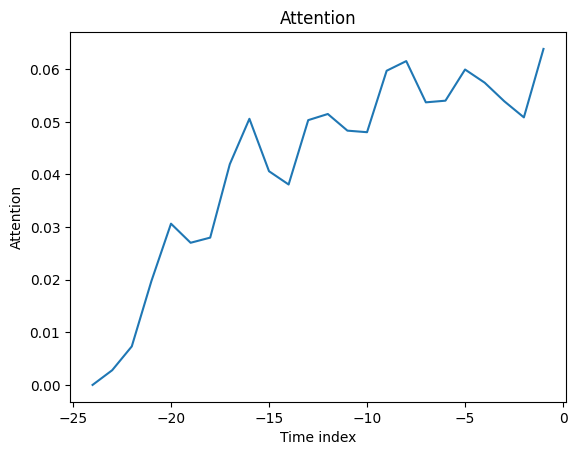

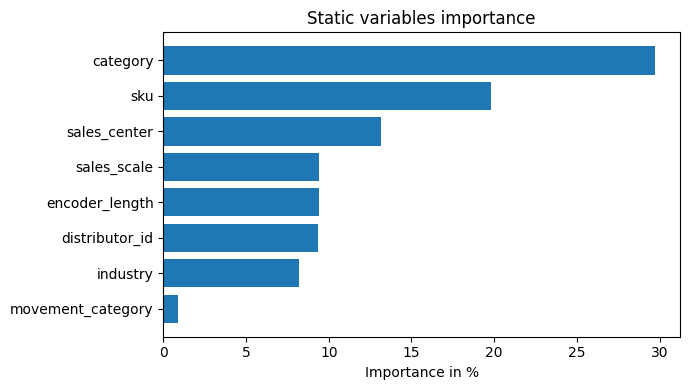

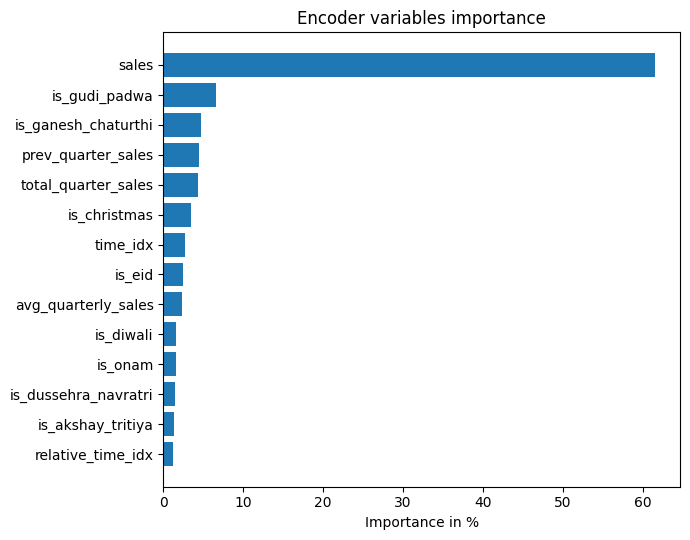

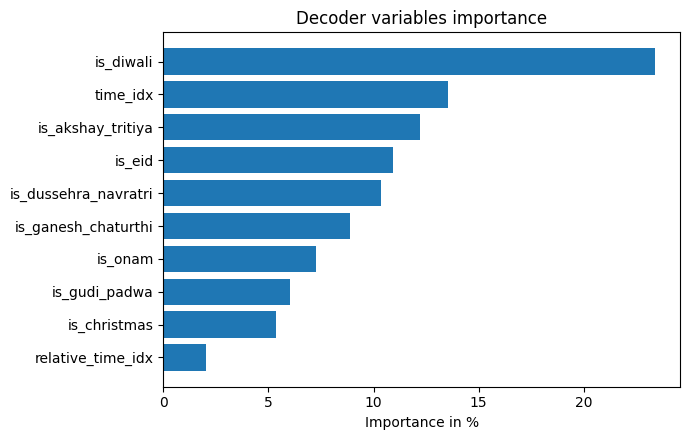

In [20]:
raw_predictions = raw_output.output
x = raw_output.x
interpretation = tft.interpret_output(raw_predictions, reduction="sum")
tft.plot_interpretation(interpretation)

In [24]:
pred_output = tft.predict(
    val_dataloader,
    return_index=True,
    return_x=False
)
type(pred_output)
preds = pred_output.output.detach().cpu().numpy().flatten()
index = pred_output.index
pred_df = index.copy()
pred_df["prediction"] = preds

pred_df.head()
val_df = df.merge(
    pred_df,
    on=["distributor_id", "sku", "time_idx"],
    how="inner"
)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


<h2>Festival WAPE</h2>

In [25]:
festival_mask = (
    (val_df["is_diwali"] == 1) |
    (val_df["is_ganesh_chaturthi"] == 1)
)

festival_df = val_df[festival_mask]

wape_festival = (
    np.sum(np.abs(festival_df["sales"] - festival_df["prediction"])) /
    np.sum(np.abs(festival_df["sales"]))
) * 100

print("Festival WAPE (%):", wape_festival)

Festival WAPE (%): 4.495159772163239


<h2>Non-Festival WAPE</h2>

In [26]:
non_festival_df = val_df[~festival_mask]

wape_non_festival = (
    np.sum(np.abs(non_festival_df["sales"] - non_festival_df["prediction"])) /
    np.sum(np.abs(non_festival_df["sales"]))
) * 100

print("Non-Festival WAPE (%):", wape_non_festival)

Non-Festival WAPE (%): 4.530348519693525


In [27]:
top_sku = (
    val_df.groupby(["distributor_id", "sku"])["sales"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

print("Top SKU:", top_sku)

Top SKU: ('DIST050', 'Louis Vuitton Neverfull Bag')


In [30]:
low_sku = (
    val_df.groupby(["distributor_id", "sku"])["sales"]
    .sum()
    .sort_values(ascending=True)
    .index[0]
)

print("Low SKU:", low_sku)

Low SKU: ('DIST029', 'Neelgagan Stamp Pad')


In [31]:
festival_effect = (
    df.groupby(["distributor_id", "sku"])
    .apply(lambda x: x.loc[x["is_diwali"]==1, "sales"].mean() -
                      x.loc[x["is_diwali"]==0, "sales"].mean())
    .sort_values(ascending=False)
)

strong_sku = festival_effect.index[0]
print("Strong Festival SKU:", strong_sku)

Strong Festival SKU: ('DIST050', 'Louis Vuitton Neverfull Bag')


/var/folders/p_/p55nsbbx3t74jm_36w0vdsg80000gn/T/ipykernel_3496/1647281133.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(["distributor_id", "sku"])
